# 8. Pulses and shots files

`sylva.Shots` stores pulses rather than points: an origin and direction per
pulse, with a CSR list of echo ranges. Pulses without a return stay in the
data, because they say where there was nothing.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import sylva
from sylva import synthetic

DATA = Path("data")          # the Litchfield tile, cut by make_litch_subset.py
plt.style.use("sylva.mplstyle")     # shared figure style; C0 to C7 are the Okabe-Ito colours
GROUND, WOOD, LEAF, GRASS, CONTEXT = "#997A5C", "#4D2B12", "#009E73", "#E69F00", "0.8"   # the same in every notebook
DIVERGING = "RdBu_r"                # for signed differences, centred on zero
LABELS = ListedColormap(["#332288", "#88CCEE", "#44AA99", "#117733", "#999933", "#DDCC77",
                         "#CC6677", "#882255", "#AA4499"])   # tree ids and clusters: Paul Tol's muted set
from sylva import Shots

The tile's pulse file came from a raycloudtools ray cloud through
`Shots.from_ray_cloud`, then `save`. Every ray was clipped to the tile, so a
ray that ends inside carries its echo and a ray that passes through (or never
returned) is a miss. That keeps the free-space information inside the tile,
but it also moves the origins onto the tile boundary: these are not pulses
from a scanner, and anything that needs true beam geometry -- gap fraction by
zenith ring, or a scan pattern -- needs the original `.rxp` (see
[Pulse data](../guide/pulses.md)).

In [2]:
shots = Shots.load(DATA / "litch_tile_shots.parquet")
print(shots)
print("misses:", f"{np.mean(shots.echo_count == 0):.0%}",
      " echoes per pulse:", dict(enumerate(np.bincount(shots.echo_count))))
print("echo attributes:", sorted(shots.echo_attrs))

Shots(n_shots=625,764, n_echoes=273,355)
misses: 56%  echoes per pulse: {0: np.int64(352409), 1: np.int64(273355)}
echo attributes: ['alpha', 'classification']


The echo arrays are flat; `echo_start` / `echo_count` say which belong to which pulse.

In [3]:
s = int(np.flatnonzero(shots.echo_count > 0)[0])
a = shots.echo_start[s]
print("pulse", s, "origin", shots.origin[s].round(2), "direction", shots.direction[s].round(3),
      "range", shots.echo_range[a].round(2))
zen, az = shots.zenith_azimuth()
first = shots.echo_rank() == 0
print("first returns:", int(first.sum()), " later returns:", int((~first).sum()))
print("zenith quartiles:", np.percentile(zen, [25, 50, 75]).round(0),
      "deg - mostly near-horizontal, because a 20 m tile is crossed by rays from the whole plot")
print("pulses with more than one echo:", int(np.sum(shots.echo_count > 1)),
      "- a ray cloud stores one echo per ray, so the multi-echo structure is already gone")

pulse 1 origin [20.    1.05  0.51] direction [-0.908 -0.417 -0.025] range 0.63
first returns: 273355  later returns: 0
zenith quartiles: [64. 79. 91.] deg - mostly near-horizontal, because a 20 m tile is crossed by rays from the whole plot
pulses with more than one echo: 0 - a ray cloud stores one echo per ray, so the multi-echo structure is already gone


Left, the share of the pulses in each direction that end in an echo
inside the tile; right, where the pulses start. The pulses of the scan
position in the corner point into the tile (azimuth 180 to 270 degrees,
clockwise from +y) and all end in it, since those going down reach the
ground. The rest entered through the sides of the tile, and many of them
cross it without a return.

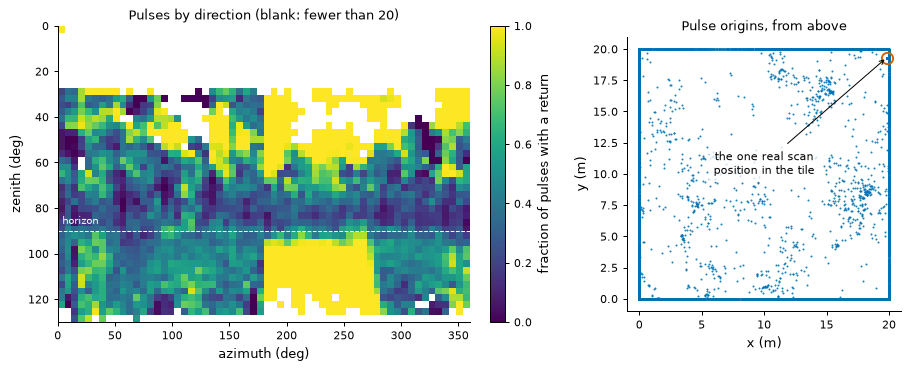

In [4]:
hit = shots.echo_count > 0
az_edges, zen_edges = np.arange(0, 361, 6), np.arange(0, 131, 3)
fired, _, _ = np.histogram2d(az, zen, [az_edges, zen_edges])
returned, _, _ = np.histogram2d(az[hit], zen[hit], [az_edges, zen_edges])
fraction = np.where(fired >= 20, returned / np.maximum(fired, 1), np.nan).T     # at least 20 pulses per cell
fig, ax = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw={"width_ratios": [1.5, 1]})
im = ax[0].imshow(fraction, origin="upper", extent=(0, 360, 130, 0), aspect="auto", vmin=0, vmax=1)
ax[0].axhline(90, c="w", lw=0.8, ls="--")
ax[0].text(4, 88, "horizon", c="w", fontsize=8, va="bottom")
fig.colorbar(im, ax=ax[0], label="fraction of pulses with a return")
ax[0].set(xlabel="azimuth (deg)", ylabel="zenith (deg)", title="Pulses by direction (blank: fewer than 20)")
ax[1].scatter(shots.origin[::20, 0], shots.origin[::20, 1], s=0.3, c="C0")
ax[1].set(title="Pulse origins, from above", xlabel="x (m)", ylabel="y (m)", aspect="equal")
keys, n = np.unique(np.round(shots.origin[:, :2], 1), axis=0, return_counts=True)
scanner = keys[n.argmax()]                    # the origin most pulses share
ax[1].plot(*scanner, "o", ms=9, mfc="none", mec="C3", mew=1.5)
ax[1].annotate("the one real scan\nposition in the tile", xy=scanner, xytext=(10, 10), ha="center", fontsize=8.5, bbox=dict(fc="white", ec="none", alpha=0.8),
               arrowprops=dict(arrowstyle="->", lw=0.8));

One scan position does fall inside the tile, in the corner, and keeps
its true origin: 38 % of the pulses here are its. The rest of the interior
scatter is not scan positions but rounding -- a ray cloud stores the vector to
the sensor as float32 next to double coordinates, so origins reconstructed 20 m
away land within a few centimetres of each other rather than exactly on the
scanner. `Shots.save(origin_tolerance=...)` collapses origins that close
together into one position when writing a shots file.

In [5]:
o = shots.origin
interior = (o[:, 0] > 0.05) & (o[:, 0] < 19.95) & (o[:, 1] > 0.05) & (o[:, 1] < 19.95)
uniq, counts = np.unique(np.round(o[interior], 1), axis=0, return_counts=True)
print(f"{interior.mean():.0%} of pulses start inside the tile, at {len(uniq):,} distinct rounded origins")
print("the biggest:", uniq[counts.argmax()], f"with {counts.max():,} pulses - the scan position")
print("the rest hold", f"{np.sort(counts)[-2]:,}", "pulses at most each - float32 rounding")

41% of pulses start inside the tile, at 18,343 distinct rounded origins
the biggest: [19.8 19.3  1.8] with 235,805 pulses - the scan position
the rest hold 6 pulses at most each - float32 rounding


Conversions: `to_pointcloud` gives the echoes as points (with `return_number`, `number_of_returns`, `range`); `from_pointcloud` and `from_ray_cloud` go the other way; `transform`, `subset` and `concatenate` behave as for point clouds.

In [6]:
points = shots.to_pointcloud()
downward = shots.subset(zen > 90)
print(points, downward, sep="\n")
print("mean echo range:", round(float(shots.echo_range.mean()), 2), "m")

PointCloud(n=273,355, attrs=['alpha', 'classification', 'number_of_returns', 'range', 'return_number'])
Shots(n_shots=164,102, n_echoes=80,616)
mean echo range: 10.3 m


## Shots files

`save` writes a Parquet file with one row per pulse: a scan index, two beam
angles and list columns for the echoes. A pulse without a return costs its two
angles and nothing else. Compare with storing the same pulses as a ray cloud,
where every miss has to become a far point carrying all its attributes.

In [7]:
import tempfile
tmp = Path(tempfile.mkdtemp())
shots.save(tmp / "tile.parquet")

miss = shots.echo_count == 0
far = shots.origin[miss] + 100 * shots.direction[miss]
ends = np.vstack([shots.echo_xyz(), far])
starts = np.vstack([shots.origin[shots.shot_of_echo()], shots.origin[miss]])
bound = np.r_[np.ones(shots.n_echoes, np.uint8), np.zeros(miss.sum(), np.uint8)]
off = (starts - ends).astype(np.float32)
sylva.write(sylva.PointCloud(ends, {"sx": off[:, 0], "sy": off[:, 1], "sz": off[:, 2], "bound": bound}),
            tmp / "rays.laz")
for f in ("tile.parquet", "rays.laz"):
    print(f"{f:14s} {(tmp / f).stat().st_size / 1e6:6.2f} MB")

tile.parquet     6.36 MB
rays.laz         7.66 MB


In [8]:
info = Shots.file_info(tmp / "tile.parquet")
print({k: v for k, v in info.items() if k != "scans"})
back = Shots.load(tmp / "tile.parquet")
print("max echo position error after the float32 round trip:",
      f"{np.abs(back.echo_xyz() - shots.echo_xyz()).max() * 1000:.3f} mm")

{'n_shots': 625764, 'n_echoes': 273355, 'n_groups': 1, 'bounds': ([-2.287577968118626e-05, -2.9545250638849894e-05, -0.06407586773921992], [19.999924388159066, 19.999882272342873, 20.08342628973494]), 'echo_attrs': ['alpha', 'classification']}
max echo position error after the float32 round trip: 0.000 mm


Any Parquet reader opens the file (polars, pyarrow, duckdb, R arrow).
Row groups can be read one at a time with `Shots.load(path, groups=[...])`, and
`sylva.voxels.ray_voxelize` accepts the path and streams it (notebook 9). For
scans read from `.rxp`, `Shots.fill_missing` reconstructs the pulses RIEGL
leaves out of the point stream; `ScanPosition.read_shots(fill_missing=True)`
does it in the right order.